In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/labeled_news.csv')

X = df['text']
y = df['sentiment']


# 80% of data for training and 20% for test
# stratify keeps same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing saples: {len(X_test)}")
print(f"\nTraining set distribution:")
print(f"\nTest set distribution:")
print(y_test.value_counts())


Training samples: 6539
Testing saples: 1635

Training set distribution:

Test set distribution:
sentiment
positive    641
neutral     602
negative    392
Name: count, dtype: int64


Training SVM model...
Training complete!

MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

    negative      0.789     0.783     0.786       392
     neutral      0.870     0.864     0.867       602
    positive      0.841     0.850     0.846       641

    accuracy                          0.839      1635
   macro avg      0.833     0.832     0.833      1635
weighted avg      0.839     0.839     0.839      1635



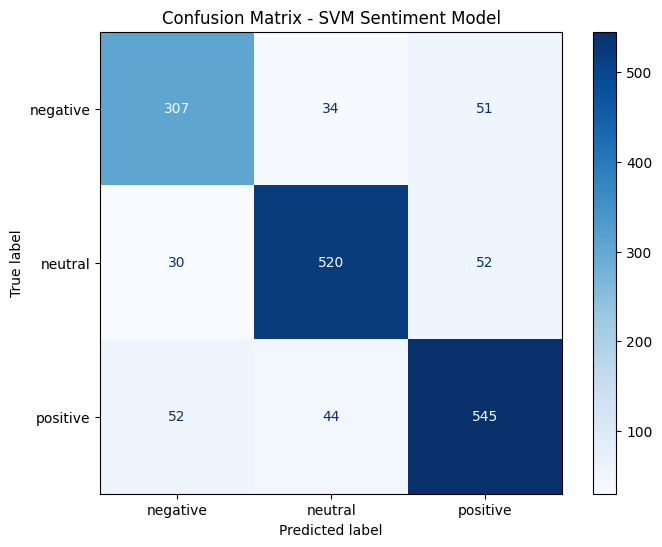


Overall Accuracy: 0.839


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Create pipeline (TF-IDF + SVM together)
svm_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=30000,        # top 10k words
        ngram_range=(1, 3),        # unigrams + bigrams
        sublinear_tf=True,         # better for text classification
        min_df=2,                  # ignore words appearing only once
        max_df=0.95                # ignore too common words
    )),
    ('svm', SVC(
        kernel='linear',           # best for text
        C=1.0,                     # regularization
        probability=True,          # IMPORTANT: needed for scores
        class_weight='balanced',   # handles imbalanced classes
        random_state=42
    ))
])

# Train
print("Training SVM model...")
svm_model.fit(X_train, y_train)
print("Training complete!")

# Predict on test set
y_pred = svm_model.predict(X_test)

# Evaluation
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['negative', 'neutral', 'positive'],
    digits=3
))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'neutral', 'positive']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - SVM Sentiment Model')
plt.savefig('../data/models/confusion_matrix.png')
plt.show()

# Overall accuracy
accuracy = (y_pred == y_test).mean()
print(f"\nOverall Accuracy: {accuracy:.3f}")

In [16]:
import os
import joblib
from sklearn.metrics import f1_score



accuracy = (y_pred == y_test).mean()
f1 = f1_score(y_test, y_pred, average = 'weighted')

print(f"Accuracy : {accuracy:.3f}")
print(f"F1 Score : {f1:.3f}")

# Save
report = classification_report(y_test,y_pred,target_names=['negative','neutral','positive'],digits = 3)

BEST_SCORE_PATH = '../data/models/best_score.txt'

# Read best score safely
if os.path.exists(BEST_SCORE_PATH):
    with open(BEST_SCORE_PATH, 'r') as f:
        best_score = float(f.read())
else:
    best_score = 0.0
    
if f1<0.80:
    print(f"Not saved -F1 {f1:.3f} below threshold")

elif f1 > best_score:
    os.makedirs('../data/models', exist_ok=True)

    joblib.dump(svm_model, '../data/models/svm_sentiment_model.pkl')

    with open(BEST_SCORE_PATH, 'w') as f:
        f.write(str(f1))

    # Save 
    with open('../data/models/classification_report.txt','w') as f:
        f.write(f"Accuracy : {accuracy:.3f}\n")
        f.write(f"F1 Score : {f1:.3f}\n\n")
        f.write(report)
    print(f"New best model saved! F1: {best_score:.3f} previous {f1:.3f}")
else:
    print(f"Kept old model. F1{f1:.3f} did not beat best:{best_score:.3f}")

Accuracy : 0.839
F1 Score : 0.839
New best model saved! F1: 0.000 previous 0.839


In [ ]:
import joblib
import os 

# After evaluation
accuracy = (y_pred == y_test).mean()
print(f"Overall Accuracy: {accuracy:.3f}")

ACCURACY_THRESHOLD = 0.80
if accuracy >= ACCURACY_THRESHOLD:
    os.makedirs('../models', exist_ok=True)
    joblib.dump(svm_model, '../models/svm_sentiment_mdoel.pkl')


Test Predictions:

Text: Tesla stock surges 15% after record quarterly deliveries
Prediction: POSITIVE
Scores: Neg=0.04 | Neu=0.00 | Pos=0.96
--------------------------------------------------------------------------------

Text: Apple faces lawsuit over privacy violations
Prediction: NEGATIVE
Scores: Neg=1.00 | Neu=0.00 | Pos=0.00
--------------------------------------------------------------------------------

Text: Amazon revenue beats expectations, stock rises
Prediction: POSITIVE
Scores: Neg=0.11 | Neu=0.01 | Pos=0.88
--------------------------------------------------------------------------------

Text: Microsoft announces layoffs affecting 10,000 employees
Prediction: NEGATIVE
Scores: Neg=0.87 | Neu=0.11 | Pos=0.02
--------------------------------------------------------------------------------

Text: Google launches new AI product with strong reviews
Prediction: POSITIVE
Scores: Neg=0.00 | Neu=0.02 | Pos=0.98
--------------------------------------------------------------------